<a href="https://colab.research.google.com/github/KDK-00/deeplearning/blob/main/Transfomer_Eng_Kor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split

import unicodedata
import re
import numpy as np
import os
import io
import time

In [2]:
path_to_file = '/content/drive/MyDrive/ko-en_translation1.CSV'

In [3]:
import pandas as pd
import re
import unicodedata

In [4]:
# def unicode_to_ascii(s):
#     return ''.join(c for c in unicodedata.normalize('NFD', s)
#                    if unicodedata.category(c) != 'Mn')

# def is_korean_sentence(sentence):
#     return bool(re.search(r'[가-힣]', sentence))

# def preprocess_sentence(w):
#     if not is_korean_sentence(w):
#         w = unicode_to_ascii(w.lower().strip())

#     # 단어와 단어 뒤에 오는 구두점(.)사이에 공백을 생성합니다.
#     w = re.sub(r"([?.!,¿])", r" \1 ", w)
#     w = re.sub(r'[" "]+', " ", w)

#     # 한국어가 아니면 (a-z, A-Z, ".", "?", "!", ",")을 제외한 모든 것을 공백으로 대체합니다.
#     if not is_korean_sentence(w):
#         w = re.sub(r"[^a-zA-Z?.!,¿]+", " ", w)
#     else:
#         # 한국어의 경우: 영어, 한글, 구두점만 남깁니다.
#         w = re.sub(r"[^가-힣a-zA-Z?.!,¿]+", " ", w)

#     w = w.strip()

#     # 문장에 start와 end 토큰을 추가합니다.
#     w = '<start> ' + w + ' <end>'
#     return w

# # 예제 문장
# en_sentence = u"May I borrow this book?"
# kr_sentence = u"이 책을 빌릴 수 있을까요?"

# # 전처리 결과 출력
# print(preprocess_sentence(en_sentence))
# print(preprocess_sentence(kr_sentence))


In [5]:
def unicode_to_ascii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn')

# def preprocess_sentence(w, is_korean=False):
#     if not is_korean:
#         w = unicode_to_ascii(w.lower().strip())

#     # 단어와 단어 뒤에 오는 구두점(.)사이에 공백을 생성합니다.
#     w = re.sub(r"([?.!,¿])", r" \1 ", w)
#     w = re.sub(r'[" "]+', " ", w)

#     # 한국어가 아니면 (a-z, A-Z, ".", "?", "!", ",")을 제외한 모든 것을 공백으로 대체합니다.
#     if not is_korean:
#         w = re.sub(r"[^a-zA-Z?.!,¿]+", " ", w)
#     else:
#         # 한국어의 경우: 영어, 한글, 구두점만 남깁니다.
#         w = re.sub(r"[^가-힣a-zA-Z?.!,¿]+", " ", w)

#     w = w.strip()

#     # 문장에 start와 end 토큰을 추가합니다.
#     w = '<start> ' + w + ' <end>'
#     return w

In [6]:
def preprocess_sentence(w):
  w = unicode_to_ascii(w.lower().strip())

  # 단어와 단어 뒤에 오는 구두점(.)사이에 공백을 생성합니다.
  # 예시: "he is a boy." => "he is a boy ."
  # 참고:- https://stackoverflow.com/questions/3645931/python-padding-punctuation-with-white-spaces-keeping-punctuation
  w = re.sub(r"([?.!,¿])", r" \1 ", w)
  w = re.sub(r'[" "]+', " ", w)

  # (a-z, A-Z, ".", "?", "!", ",")을 제외한 모든 것을 공백으로 대체합니다.
  w = re.sub(r"[^a-zA-Z가-힣?.!,¿]+", " ", w)

  w = w.strip()

  # 모델이 예측을 시작하거나 중단할 때를 알게 하기 위해서
  # 문장에 start와 end 토큰을 추가합니다.
  w = '<start> ' + w + ' <end>'
  return w

In [7]:
def preprocess_sentence_kr(w):
  w = w.strip()

  # 단어와 단어 뒤에 오는 구두점(.)사이에 공백을 생성합니다.
  # 예시: "he is a boy." => "he is a boy ."
  # 참고:- https://stackoverflow.com/questions/3645931/python-padding-punctuation-with-white-spaces-keeping-punctuation
  w = re.sub(r"([?.!,¿])", r" \1 ", w)
  w = re.sub(r'[" "]+', " ", w)

  w = re.sub(r'[ |ㄱ-ㅎ|ㅏ-ㅣ]+', " ", w)

  w = w.strip()

  # 모델이 예측을 시작하거나 중단할 때를 알게 하기 위해서
  # 문장에 start와 end 토큰을 추가합니다.
  w = '<start> ' + w + ' <end>'
  return w

In [8]:
en_sentence = u"May I borrow this book?"
kr_sentence = u"이 책을 빌릴 수 있을까요?"
print(preprocess_sentence(en_sentence))
print(preprocess_sentence_kr(kr_sentence))

<start> may i borrow this book ? <end>
<start> 이 책을 빌릴 수 있을까요 ? <end>


In [9]:
df = pd.read_csv(path_to_file, encoding='UTF-8')
df.columns = ["num","kor", "en"]
df

,num,kor,en
0,1,'Bible Coloring'은 성경의 아름다운 이야기를 체험 할 수 있는 컬러링 ...,Bible Coloring' is a coloring application that...
1,2,씨티은행에서 일하세요?,Do you work at a City bank?
2,3,푸리토의 베스트셀러는 해외에서 입소문만으로 4차 완판을 기록하였다.,"PURITO's bestseller, which recorded 4th rough ..."
3,4,11장에서는 예수님이 이번엔 나사로를 무덤에서 불러내어 죽은 자 가운데서 살리셨습니다.,In Chapter 11 Jesus called Lazarus from the to...
4,5,"6.5, 7, 8 사이즈가 몇 개나 더 재입고 될지 제게 알려주시면 감사하겠습니다.",I would feel grateful to know how many stocks ...
...,...,...,...
199995,199996,나는 먼저 청소기로 바닥을 밀었어요.,"First of all, I vacuumed the floor."
199996,199997,나는 먼저 팀 과제를 하고 놀러 갔어요.,I did the team assignment first and went out t...
199997,199998,나는 비 같은 멋진 연예인을 좋아해요.,I like cool entertainer like Rain.
199998,199999,나는 멋진 자연 경치를 보고 눈물을 흘렸어.,I cried seeing the amazing scenery.


In [10]:
def create_dataset(path, num_examples):
  df = pd.read_csv(path_to_file)
  df.columns = ["num","kor", "en"]

  if num_examples is not None:
        df = df.iloc[:num_examples]

  en = [preprocess_sentence(l) for l in df['en']]
  kr = [preprocess_sentence_kr(l) for l in df['kor']]



  # 다음과 같은 형식으로 문장의 쌍을 반환합니다: [영어, 한국어]
  return en, kr # 이렇게 하면 한->영 번역이 됨

In [11]:
en, kr = create_dataset(path_to_file, None)
print(en[-1])
print(kr[-1])

<start> i look forward to a great middle school experience . <end>
<start> 나는 멋진 중학교 생활을 기대합니다 . <end>


In [12]:
# def create_dataset(df, num_examples):
#     word_pairs = []
#     for index, row in df.iterrows():
#         if num_examples and index >= num_examples:
#             break
#         kr = row['원문']
#         en = row['번역문']
#         word_pairs.append([preprocess_sentence(en), preprocess_sentence(kr, is_korean=True)])

#     return zip(*word_pairs)



In [13]:
# # 병렬 문장 쌍 생성
# en, kr = create_dataset(df, None)

# en = list(en)
# kr = list(kr)

# print(en[0])
# print(kr[0])

In [14]:
def tokenize(lang):
  lang_tokenizer = tf.keras.preprocessing.text.Tokenizer(
      filters='')
  lang_tokenizer.fit_on_texts(lang)

  tensor = lang_tokenizer.texts_to_sequences(lang)

  tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor,padding='post')

  return tensor, lang_tokenizer

In [15]:
# def load_dataset(path, num_examples=None):
#   # 전처리된 타겟 문장과 입력 문장 쌍을 생성합니다
#   targ_lang, inp_lang = create_dataset(path, num_examples)

#   input_tensor, inp_lang_tokenizer = tokenize(inp_lang)
#   target_tensor, targ_lang_tokenizer = tokenize(targ_lang)

#   return input_tensor, target_tensor, inp_lang_tokenizer, targ_lang_tokenizer

In [16]:
def load_dataset(path, num_examples=None):
  # Load the DataFrame from the provided path
  df = pd.read_csv(path, encoding='UTF-8')

  # 전처리된 타겟 문장과 입력 문장 쌍을 생성합니다
  targ_lang, inp_lang = create_dataset(df, num_examples) # Pass the DataFrame to create_dataset

  input_tensor, inp_lang_tokenizer = tokenize(inp_lang)
  target_tensor, targ_lang_tokenizer = tokenize(targ_lang)

  return input_tensor, target_tensor, inp_lang_tokenizer, targ_lang_tokenizer

In [17]:
# 언어 데이터셋을 아래의 크기로 제한하여 훈련과 검증을 수행합니다.
num_examples = 30000
input_tensor, target_tensor, inp_lang, targ_lang = load_dataset(path_to_file, num_examples)

# 타겟 텐서와 입력 텐서의 최대 길이를 계산합니다.
max_length_targ, max_length_inp = target_tensor.shape[1], input_tensor.shape[1]

In [18]:
# 훈련 집합과 검증 집합을 80대 20으로 분리합니다.
input_tensor_train, input_tensor_val, target_tensor_train, target_tensor_val = train_test_split(input_tensor, target_tensor, test_size=0.2)

# 훈련 집합과 검증 집합의 데이터 크기를 출력합니다.
print(len(input_tensor_train), len(target_tensor_train), len(input_tensor_val), len(target_tensor_val))

24000 24000 6000 6000


In [19]:
def convert(lang, tensor):
  for t in tensor:
    if t!=0:
      print ("%d ----> %s" % (t, lang.index_word[t]))

In [20]:
print ("Input Language; index to word mapping")
convert(inp_lang, input_tensor_train[0])
print ()
print ("Target Language; index to word mapping")
convert(targ_lang, target_tensor_train[0])

Input Language; index to word mapping
1 ----> <start>
11 ----> 그것은
11391 ----> 심장을
10762 ----> 강하게
45 ----> 하고
16155 ----> 면역력을
56139 ----> 높여줍니다
3 ----> .
2 ----> <end>

Target Language; index to word mapping
1 ----> <start>
12 ----> it
9231 ----> strengthens
4 ----> the
590 ----> heart
11 ----> and
3635 ----> improves
4 ----> the
6389 ----> immune
380 ----> system
3 ----> .
2 ----> <end>


In [21]:
BUFFER_SIZE = len(input_tensor_train)
BATCH_SIZE = 64
steps_per_epoch = len(input_tensor_train) // BATCH_SIZE
embedding_dim = 256
units = 1024
vocab_inp_size = len(inp_lang.word_index)+1
vocab_tar_size = len(targ_lang.word_index)+1

dataset = tf.data.Dataset.from_tensor_slices((input_tensor_train, target_tensor_train)).shuffle(BUFFER_SIZE)
dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)

In [22]:
example_input_batch, example_target_batch = next(iter(dataset))
example_input_batch.shape, example_target_batch.shape

(TensorShape([64, 32]), TensorShape([64, 48]))

In [23]:
class Encoder(tf.keras.Model):
  def __init__(self, vocab_size, embedding_dim, enc_units, batch_sz):
    super(Encoder, self).__init__()
    self.batch_sz = batch_sz
    self.enc_units = enc_units
    self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
    self.gru = tf.keras.layers.GRU(self.enc_units, return_sequences=True, return_state=True, recurrent_initializer = 'glorot_uniform')

  def call(self, x, hidden):
    x = self.embedding(x)
    output, state = self.gru(x, initial_state = hidden)
    return output, state

  def initialize_hidden_state(self):
    return tf.zeros((self.batch_sz, self.enc_units))

In [24]:
encoder = Encoder(vocab_inp_size, embedding_dim, units, BATCH_SIZE)

#샘플 입력
sample_hidden = encoder.initialize_hidden_state()
sample_output, sample_hidden = encoder(example_input_batch, sample_hidden)
print('Encoder output shape: (batch size, sequence length, units) {}'.format(sample_output.shape))
print('Encoder Hidden state shape: (batch size, units) {}'.format(sample_hidden.shape))

Encoder output shape: (batch size, sequence length, units) (64, 32, 1024)
Encoder Hidden state shape: (batch size, units) (64, 1024)


In [25]:
class BahdanauAttention(tf.keras.layers.Layer):
  def __init__(self, units):
    super(BahdanauAttention, self).__init__()
    self.W1 = tf.keras.layers.Dense(units)
    self.W2 = tf.keras.layers.Dense(units)
    self.V = tf.keras.layers.Dense(1)

  def call(self, query, values):
    # query hidden state shape == (batch_size, hidden size)
    # query_with_time_axis shape == (batch_size, 1, hidden size)
    query_with_time_axis = tf.expand_dims(query, 1)

    # score shape == (batch_size, max_length, 1)
    # we get 1 at the last axis because we are applying score to self.V
    # the shape of the tensor before applying self.V is (batch_size, max_length, units)
    score = self.V(tf.nn.tanh(
        self.W1(query_with_time_axis) + self.W2(values)))

    # attention_weights shape == (batch_size, max_length, 1)
    attention_weights = tf.nn.softmax(score, axis=1)

    # context_vector shape after sum == (batch_size, hidden_size)
    context_vector = attention_weights * values
    context_vector = tf.reduce_sum(context_vector, axis=1)

    return context_vector, attention_weights

In [26]:
attention_layer = BahdanauAttention(10)
attention_result, attention_weights = attention_layer(sample_hidden, sample_output)

print("Attention result shape: (batch size, units) {}".format(attention_result.shape))
print("Attention weights shape: (batch_size, sequence_length, 1) {}".format(attention_weights.shape))

Attention result shape: (batch size, units) (64, 1024)
Attention weights shape: (batch_size, sequence_length, 1) (64, 32, 1)


In [27]:
class Decoder(tf.keras.Model):
  def __init__(self, vocab_size, embedding_dim, dec_units, batch_sz):
    super(Decoder, self).__init__()
    self.batch_sz = batch_sz
    self.dec_units = dec_units
    self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
    self.gru = tf.keras.layers.GRU(self.dec_units,
                                   return_sequences=True,
                                   return_state=True,
                                   recurrent_initializer='glorot_uniform')
    self.fc = tf.keras.layers.Dense(vocab_size)

    # 어텐션을 사용합니다.
    self.attention = BahdanauAttention(self.dec_units)

  def call(self, x, hidden, enc_output):
    # enc_output는 (batch_size, max_length, hidden_size)쌍으로 이루어져 있습니다.
    context_vector, attention_weights = self.attention(hidden, enc_output)

    # 임베딩층을 통과한 후 x는 (batch_size, 1, embedding_dim)쌍으로 이루어져 있습니다.
    x = self.embedding(x)

    # 컨텍스트 벡터와 임베딩 결과를 결합한 이후 x의 형태는 (batch_size, 1, embedding_dim + hidden_size)쌍으로 이루어져 있습니다.
    x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)

    # 위에서 결합된 벡터를 GRU에 전달합니다.
    output, state = self.gru(x)

    # output은 (batch_size * 1, hidden_size)쌍으로 이루어져 있습니다.
    output = tf.reshape(output, (-1, output.shape[2]))

    # output은 (batch_size, vocab)쌍으로 이루어져 있습니다.
    x = self.fc(output)

    return x, state, attention_weights

In [28]:
decoder = Decoder(vocab_tar_size, embedding_dim, units, BATCH_SIZE)

sample_decoder_output, _, _ = decoder(tf.random.uniform((BATCH_SIZE, 1)),
                                      sample_hidden, sample_output)

print ('Decoder output shape: (batch_size, vocab size) {}'.format(sample_decoder_output.shape))

Decoder output shape: (batch_size, vocab size) (64, 17170)


In [29]:
optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')

def loss_function(real, pred):
  mask = tf.math.logical_not(tf.math.equal(real, 0))
  loss_ = loss_object(real, pred)

  mask = tf.cast(mask, dtype=loss_.dtype)
  loss_ *= mask

  return tf.reduce_mean(loss_)

In [30]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(optimizer=optimizer,
                                 encoder=encoder,
                                 decoder=decoder)

In [31]:
@tf.function
def train_step(inp, targ, enc_hidden):
  loss = 0

  with tf.GradientTape() as tape:
    enc_output, enc_hidden = encoder(inp, enc_hidden)

    dec_hidden = enc_hidden

    dec_input = tf.expand_dims([targ_lang.word_index['<start>']] * BATCH_SIZE, 1)

    # 교사 강요(teacher forcing) - 다음 입력으로 타겟을 피딩(feeding)합니다.
    for t in range(1, targ.shape[1]):
      # enc_output를 디코더에 전달합니다.
      predictions, dec_hidden, _ = decoder(dec_input, dec_hidden, enc_output)

      loss += loss_function(targ[:, t], predictions)

      # 교사 강요(teacher forcing)를 사용합니다.
      dec_input = tf.expand_dims(targ[:, t], 1)

  batch_loss = (loss / int(targ.shape[1]))

  variables = encoder.trainable_variables + decoder.trainable_variables

  gradients = tape.gradient(loss, variables)

  optimizer.apply_gradients(zip(gradients, variables))

  return batch_loss

In [32]:
EPOCHS = 10

for epoch in range(EPOCHS):
  start = time.time()

  enc_hidden = encoder.initialize_hidden_state()
  total_loss = 0

  for (batch, (inp, targ)) in enumerate(dataset.take(steps_per_epoch)):
    batch_loss = train_step(inp, targ, enc_hidden)
    total_loss += batch_loss

    if batch % 100 == 0:
      print('Epoch {} Batch {} Loss {:.4f}'.format(epoch + 1,
                                                   batch,
                                                   batch_loss.numpy()))
  # 에포크가 2번 실행될때마다 모델 저장 (체크포인트)
  if (epoch + 1) % 2 == 0:
    checkpoint.save(file_prefix = checkpoint_prefix)

  print('Epoch {} Loss {:.4f}'.format(epoch + 1,
                                      total_loss / steps_per_epoch))
  print('Time taken for 1 epoch {} sec\n'.format(time.time() - start))

Epoch 1 Batch 0 Loss 2.5773
Epoch 1 Batch 100 Loss 1.7025
Epoch 1 Batch 200 Loss 1.5903
Epoch 1 Batch 300 Loss 1.6110
Epoch 1 Loss 1.6406
Time taken for 1 epoch 261.5263032913208 sec

Epoch 2 Batch 0 Loss 1.3690
Epoch 2 Batch 100 Loss 1.5403
Epoch 2 Batch 200 Loss 1.5693
Epoch 2 Batch 300 Loss 1.5202
Epoch 2 Loss 1.4542
Time taken for 1 epoch 200.318452835083 sec

Epoch 3 Batch 0 Loss 1.2555
Epoch 3 Batch 100 Loss 1.3514
Epoch 3 Batch 200 Loss 1.3754
Epoch 3 Batch 300 Loss 1.2535
Epoch 3 Loss 1.3492
Time taken for 1 epoch 194.93065905570984 sec

Epoch 4 Batch 0 Loss 1.3208
Epoch 4 Batch 100 Loss 1.1854
Epoch 4 Batch 200 Loss 1.3223
Epoch 4 Batch 300 Loss 1.2792
Epoch 4 Loss 1.2617
Time taken for 1 epoch 199.91146111488342 sec

Epoch 5 Batch 0 Loss 1.1975
Epoch 5 Batch 100 Loss 1.0801
Epoch 5 Batch 200 Loss 1.1577
Epoch 5 Batch 300 Loss 1.0863
Epoch 5 Loss 1.1778
Time taken for 1 epoch 194.76582860946655 sec

Epoch 6 Batch 0 Loss 1.0624
Epoch 6 Batch 100 Loss 1.0487
Epoch 6 Batch 200 Lo

In [33]:
def evaluate(sentence):
  attention_plot = np.zeros((max_length_targ, max_length_inp))

  sentence = preprocess_sentence_kr(sentence) #한영 번역

  inputs = [inp_lang.word_index[i] for i in sentence.split(' ')]
  inputs = tf.keras.preprocessing.sequence.pad_sequences([inputs],
                                                         maxlen=max_length_inp,
                                                         padding='post')
  inputs = tf.convert_to_tensor(inputs)

  result = ''

  hidden = [tf.zeros((1, units))]
  enc_out, enc_hidden = encoder(inputs, hidden)

  dec_hidden = enc_hidden
  dec_input = tf.expand_dims([targ_lang.word_index['<start>']], 0)

  for t in range(max_length_targ):
    predictions, dec_hidden, attention_weights = decoder(dec_input,
                                                         dec_hidden,
                                                         enc_out)

    # 나중에 어텐션 가중치를 시각화하기 위해 어텐션 가중치를 저장합니다.
    attention_weights = tf.reshape(attention_weights, (-1, ))
    attention_plot[t] = attention_weights.numpy()

    predicted_id = tf.argmax(predictions[0]).numpy()

    result += targ_lang.index_word[predicted_id] + ' '

    if targ_lang.index_word[predicted_id] == '<end>':
      return result, sentence, attention_plot

    # 예측된 ID를 모델에 다시 피드합니다.
    dec_input = tf.expand_dims([predicted_id], 0)

  return result, sentence, attention_plot

In [34]:
# 어텐션 가중치를 그리기 위한 함수입니다.
def plot_attention(attention, sentence, predicted_sentence):
  fig = plt.figure(figsize=(10,10))
  ax = fig.add_subplot(1, 1, 1)
  ax.matshow(attention, cmap='viridis')

  fontdict = {'fontsize': 14}

  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)

  ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
  ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

  plt.show()

In [35]:
def translate(sentence):
  result, sentence, attention_plot = evaluate(sentence)

  print('Input: %s' % (sentence))
  print('Predicted translation: {}'.format(result))

  attention_plot = attention_plot[:len(result.split(' ')), :len(sentence.split(' '))]
  plot_attention(attention_plot, sentence.split(' '), result.split(' '))

In [39]:
# checkpoint_dir내에 있는 최근 체크포인트(checkpoint)를 복원합니다.
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

Input: <start> 안녕 하세요 저는 입니다 . <end>
Predicted translation: please let s have any inconvenience while changing ppt file . <end> 


<ipython-input-34-833ef93d3930>:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
<ipython-input-34-833ef93d3930>:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


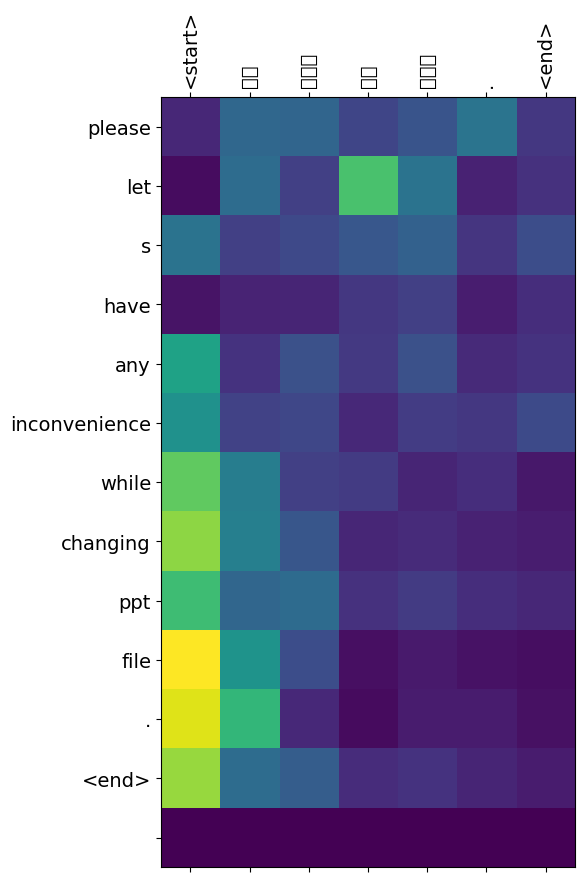

In [40]:
translate(u'안녕 하세요 저는 입니다 .')